In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dados = pd.read_csv('bankloans.csv')

In [3]:
dados

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0
...,...,...,...,...,...,...,...,...,...
1145,34,1,12,15,32,2.7,0.239328,0.624672,NaN
1146,32,2,12,11,116,5.7,4.026708,2.585292,NaN
1147,48,1,13,11,38,10.8,0.722304,3.381696,NaN
1148,35,2,1,11,24,7.8,0.417456,1.454544,NaN


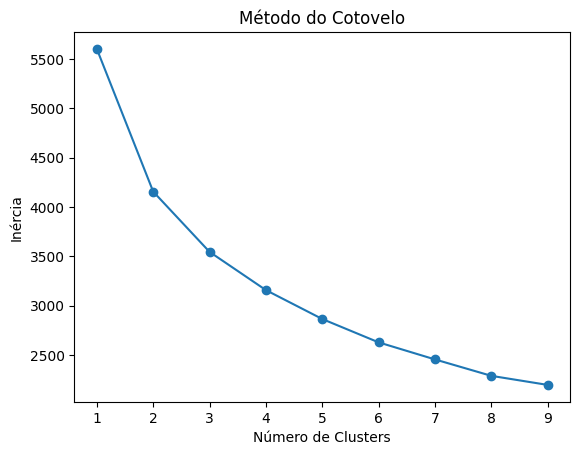

In [4]:
# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

dados = dados.dropna()
features = [
    'age', 'ed', 'employ', 'address',
    'income', 'debtinc', 'creddebt',
    'othdebt',
]

X = dados[features]

# =========================
# 2. Normalização
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 3. Escolher número de clusters (Elbow)
# =========================
inertia = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

dados['cluster'] = clusters

/var/folders/15/5lxjr81s7j5bmc845br6c1d40000gn/T/ipykernel_87013/1650942912.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados['cluster'] = clusters


/var/folders/15/5lxjr81s7j5bmc845br6c1d40000gn/T/ipykernel_87013/547583279.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados['pca1'] = X_pca[:, 0]
/var/folders/15/5lxjr81s7j5bmc845br6c1d40000gn/T/ipykernel_87013/547583279.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados['pca2'] = X_pca[:, 1]


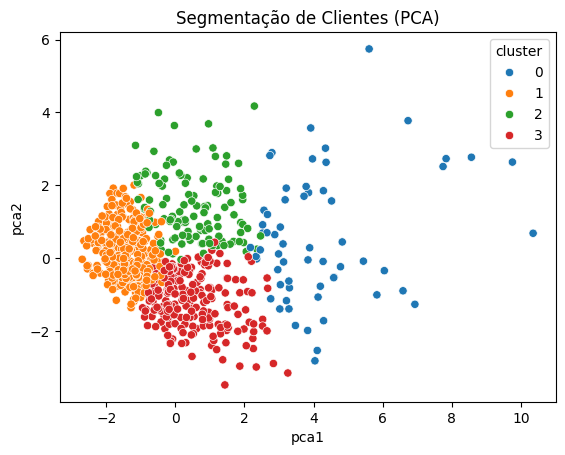

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dados['pca1'] = X_pca[:, 0]
dados['pca2'] = X_pca[:, 1]

plt.figure()
sns.scatterplot(data=dados, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('Segmentação de Clientes (PCA)')
plt.show()

In [14]:
cluster_profile = dados.groupby('cluster')[features].mean()
print(cluster_profile)

               age        ed     employ    address      income    debtinc  \
cluster                                                                     
0        43.622951  1.983607  18.967213  14.049180  120.098361  16.067213   
1        28.838284  1.666667   4.465347   4.188119   27.297030   7.741254   
2        34.394958  1.966387   6.689076   7.873950   39.210084  19.788235   
3        41.059908  1.594470  11.824885  12.589862   53.723502   6.921198   

         creddebt    othdebt  
cluster                       
0        5.812712  10.442271  
1        0.618554   1.397859  
2        2.398634   5.040140  
3        1.198398   2.214007  
